In [1]:
import numpy as np
import pandas as pd
import torch
import h5py
import joblib
import os, sys
import subprocess
import matplotlib.pyplot as plt
import math, json

In [2]:
sys.path.insert(0, "/mnt/efsUCE/umap_pytorch")  #git+https://github.com/ucscBrainExplorer/umap_pytorch.git
import umap_pytorch
print(umap_pytorch.__file__)

/mnt/efsUCE/umap_pytorch/umap_pytorch/__init__.py


In [3]:
results_dir = "combined_UCE_20M_Brain_NervousSystem_shuffled"

embedding_h5_file = "pca.h5"
embedding_h5_file_key = "pca"
knn_outfile = "knn_30.npz"

#metadata_file = "obs_anno.tsv"
#metadata_feature = "Gabitto_cell_type/Siletti_supercluster/BG_group" #"Subclass"

output_dir = "combined_UCE_20M_Brain_NervousSystem_shuffled"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

existing_model_iteration = 58
epochs = 5

## Load Embedding (pca) back into memory

In [4]:
# Load the embedding data
# Open the HDF5 file
with h5py.File(os.path.join(results_dir, embedding_h5_file), "r") as f:
    X_data = f[embedding_h5_file_key][:]

## Load Knn Back

In [5]:
# load knn back
data = np.load(os.path.join(results_dir, knn_outfile))
knn_indices = data["indices"]
knn_distances = data["distances"]

## PUMAP 
using umap_pytorch https://github.com/ucscBrainExplorer/umap_pytorch.git

## set up training on all cells

In [6]:
knn_indices = knn_indices[:,:10]
knn_dists = knn_distances[:,:10]
#knn_indices = knn_indices[:,:15]
#knn_dists = knn_distances[:,:15]

In [7]:
# Convert to PyTorch tensor so to use gpu
data_tensor = torch.from_numpy(X_data)
data_tensor, data_tensor.shape

(tensor([[ 0.1414,  0.1976, -0.0437,  ..., -0.0062, -0.0409,  0.0107],
         [ 0.1620,  0.1789, -0.0531,  ...,  0.0105, -0.0728, -0.0248],
         [ 0.1647,  0.1655, -0.0316,  ..., -0.0531, -0.0491,  0.0004],
         ...,
         [ 0.0812, -0.1499,  0.1511,  ...,  0.0053, -0.0358,  0.0289],
         [ 0.0686, -0.1405,  0.1745,  ...,  0.0255, -0.0275,  0.0257],
         [-0.0493, -0.1290, -0.0158,  ..., -0.0153, -0.0164, -0.0397]]),
 torch.Size([20019666, 50]))

### Load model back or start with a new model

In [8]:
if existing_model_iteration > 0:
    from umap_pytorch import load_pumap
    path = os.path.join(output_dir, f'pytorch_e{existing_model_iteration}.pkl')
    pumap = load_pumap(path)
    pumap.epochs = epochs
    print ("Start with existing model", f'pytorch_e{existing_model_iteration}.pkl')
else:
    import torch.nn.functional as F
    pumap = umap_pytorch.PUMAP(
        encoder=None,           # nn.Module, None for default
        decoder=None,           # nn.Module, True for default, None for encoder only
        n_neighbors=10,
        min_dist= 0.1,
        metric="euclidean",
        n_components=2,
        beta=1.0,               # How much to weigh reconstruction loss for decoder
        reconstruction_loss=F.binary_cross_entropy_with_logits, # pass in custom reconstruction loss functions
        random_state=None,
        lr=1e-3,
        epochs=epochs, #5,
        batch_size= 512, #256, #64, # gpu memory related
        num_workers=0, #10,
        num_gpus=1,
        match_nonparametric_umap=False, # Train network to match embeddings from non parametric umap,
    )
    print ("Start with a new model")

Loading PUMAP object from pickled file.
Start with existing model pytorch_e58.pkl


### Train

In [9]:
existing_model_iteration, pumap.epochs

(58, 5)

In [10]:
np.product = np.prod  # alias to fix compatibility
pumap.fit(data_tensor, knn_indices, knn_dists)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ec2-user/.local/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Fitting parametric Umap
There are knn provided by the user
Start fuzzy_simplicial_set ...
End fuzzy_simplicial_set
Training start
Start UMAPDataset initiation ...
batch_size: 512


/mnt/efsUCE/umap_pytorch/umap_pytorch/data.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(data, device="cuda")


End UMAPDataset. 23969488896 20019666


You are using a CUDA device ('NVIDIA A10G') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type            | Params | Mode 
----------------------------------------------------
0 | encoder | default_encoder | 91.0 K | train
----------------------------------------------------
91.0 K    Trainable params
0         Non-trainable params
91.0 K    Total params
0.364     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


dataloader len: 39100


/home/ec2-user/.local/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                   …

`Trainer.fit` stopped: `max_epochs=5` reached.


### Saving model

In [11]:
model_path = os.path.join(output_dir, f'pytorch_e{existing_model_iteration + pumap.epochs}.pkl')
pumap.save(model_path)

Pickled PUMAP object at combined_UCE_20M_Brain_NervousSystem_shuffled/pytorch_e63.pkl


In [12]:
existing_model_iteration = existing_model_iteration+ pumap.epochs
existing_model_iteration

63

In [13]:
# load model
"""
from umap_pytorch import load_pumap
model_path = 'combined_UCE_5neuro/pytorch_e31.pkl'
pumap = load_pumap(model_path)
print("Loaded model", f'pytorch_e{existing_model_iteration}.pkl')
"""

'\nfrom umap_pytorch import load_pumap\nmodel_path = \'combined_UCE_5neuro/pytorch_e31.pkl\'\npumap = load_pumap(model_path)\nprint("Loaded model", f\'pytorch_e{existing_model_iteration}.pkl\')\n'

In [14]:
#sys.exit()

### Quick viz X_umap_pytorch

#### random 1M

In [15]:
view_size = 1_000_000
np.random.seed(42)  # set seed for reproducibility
subset_indices = np.random.choice(X_data.shape[0], size= view_size, replace=False)

In [16]:
X_umap_pytorch = pumap.transform(data_tensor[subset_indices])

Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)


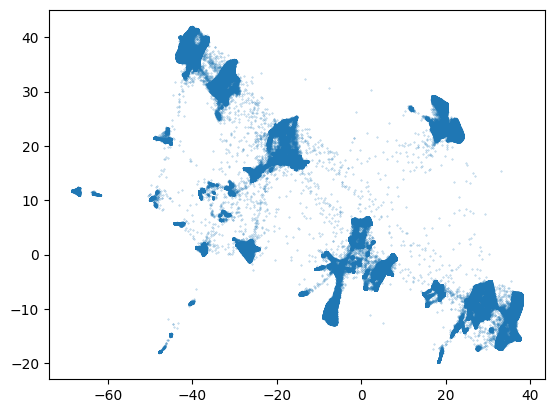

In [17]:
# current
plt.scatter(X_umap_pytorch[:,0], X_umap_pytorch[:,1], alpha =0.5, s=0.1)
plt.show()

### Save UMAP

In [18]:
n_samples = data_tensor.shape[0]
embedding_dim = 2  # since n_components=2
X_umap_pytorch = np.zeros((n_samples, embedding_dim), dtype=np.float32)

# --- Batch transform ---
print("Starting batch transformation ...", flush=True)
batch_size = 1_000_000
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    batch = data_tensor[start:end]
    emb = pumap.transform(batch)
    X_umap_pytorch[start:end] = emb
    print(f"Processed {end}/{n_samples}", flush=True)

Starting batch transformation ...
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 1000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 2000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 3000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 4000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 5000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 6000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 7000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 8000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 9000000/20019666
Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
Processed 10000000/20019666
Reducing array of shape torch.Size(

In [19]:
config = {}
model_path = os.path.join(output_dir, f'pytorch_e{existing_model_iteration}.pkl')
config["pumap_model_file"] = model_path
config["pca_model_file"]= os.path.join(output_dir,"ipca_model.pkl") # hard-coded for ipca transformation

# --- Axis adjustment ---
UMAP1_size = np.ptp(X_umap_pytorch[:, 0])
UMAP2_size = np.ptp(X_umap_pytorch[:, 1])
if UMAP1_size < UMAP2_size:
    print("Swapping axes (too tall UMAP)...", flush=True)
    X_umap_pytorch[:, [0, 1]] = X_umap_pytorch[:, [1, 0]]
    config["swap_xy_matrix"] =  [
        [0, 1],
        [1, 0]
    ]
else:
    config["swap_xy_matrix"] =  [
        [1, 0],
        [0, 1]
    ]
config

{'pumap_model_file': 'combined_UCE_20M_Brain_NervousSystem_shuffled/pytorch_e63.pkl',
 'pca_model_file': 'combined_UCE_20M_Brain_NervousSystem_shuffled/ipca_model.pkl',
 'swap_xy_matrix': [[1, 0], [0, 1]]}

In [20]:
# --- Saveing transformation config ----
config_path = os.path.join(output_dir, f"transform_e{existing_model_iteration}.json")
with open(config_path, "w") as f:
    json.dump(config, f)

In [21]:
# --- Save umap ----
umap_file = f"umap_e{existing_model_iteration}.npy"
output_path = os.path.join(output_dir, umap_file)
np.save(output_path, X_umap_pytorch)